# Gradient Descent, From Scratch

Every model that "learns" is really just gradient descent wearing a costume. This notebook implements three variants from scratch in numpy — no `scipy.optimize`, no autograd — and races them on two loss surfaces so you can see *why* the variants exist, not just what they're called:

- **Batch gradient descent** — follow the true gradient, every step
- **Momentum** — accumulate velocity, so the path stops zig-zagging
- **Noisy / SGD-style** — inject noise into the gradient, mimicking what a mini-batch gradient actually looks like

The first surface is deliberately an elongated bowl (steep in one direction, shallow in the other) — the shape that makes vanilla gradient descent visibly struggle and makes momentum's advantage obvious. The second is harder and more realistic: two basins of different depth, separated by a ridge — the shape that makes a shallow **local minimum** a real risk, not just a textbook footnote.

The companion interactive version lives at `web/` — same math, both surfaces, three optimizers racing live in the browser.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor": "#1a1a19",
    "axes.edgecolor": "#383835",
    "axes.labelcolor": "#ffffff",
    "text.color": "#ffffff",
    "xtick.color": "#c3c2b7",
    "ytick.color": "#c3c2b7",
    "grid.color": "#2c2c2a",
    "axes.grid": True,
    "grid.linewidth": 0.5,
    "font.size": 11,
})

COLORS = {
    "batch": "#3987e5",
    "momentum": "#d95926",
    "sgd": "#199e70",
}

## The loss surface

$$L(w_1, w_2) = \tfrac{1}{2}\left(a\, w_1^2 + b\, w_2^2\right), \qquad \nabla L = (a\, w_1,\; b\, w_2)$$

With $a=1$ and $b=8$, the bowl is eight times steeper along $w_2$ than $w_1$. This is a stand-in for what a real loss surface often looks like near a good minimum — curved much more sharply in some directions than others.

In [2]:
A, B = 1.0, 8.0  # curvature along w1, w2

def loss(w: np.ndarray) -> float:
    return 0.5 * (A * w[0] ** 2 + B * w[1] ** 2)

def grad(w: np.ndarray) -> np.ndarray:
    return np.array([A * w[0], B * w[1]])

w_start = np.array([3.5, 3.5])
print("start loss:", loss(w_start))
print("start grad:", grad(w_start))

start loss: 55.125
start grad: [ 3.5 28. ]


## Batch gradient descent

$$w_{t+1} = w_t - \eta \, \nabla L(w_t)$$

Take the true gradient, step directly against it, repeat. Simple, and on a lopsided bowl like this one, prone to zig-zagging: a learning rate large enough to make progress along the shallow axis will overshoot along the steep one.

In [3]:
def run_batch_gd(w0: np.ndarray, lr: float, n_steps: int) -> np.ndarray:
    path = np.zeros((n_steps + 1, 2))
    path[0] = w0
    w = w0.copy()
    for t in range(n_steps):
        w = w - lr * grad(w)
        path[t + 1] = w
    return path


batch_path = run_batch_gd(w_start, lr=0.2, n_steps=30)
print("final w:", batch_path[-1], "final loss:", loss(batch_path[-1]))

final w: [4.33279014e-03 7.73758719e-07] final loss: 9.386537582613788e-06


## Momentum

$$v_{t+1} = \beta v_t + \nabla L(w_t) \qquad w_{t+1} = w_t - \eta\, v_{t+1}$$

Instead of stepping against the raw gradient, accumulate a velocity that's a running average of past gradients. Steep-axis gradients keep flipping sign step to step, so they cancel out in the average; shallow-axis gradients keep the same sign, so they build up. Net effect: the zig-zag along the steep axis damps out, and progress along the shallow axis accelerates.

In [4]:
def run_momentum_gd(w0: np.ndarray, lr: float, n_steps: int, beta: float = 0.85) -> np.ndarray:
    path = np.zeros((n_steps + 1, 2))
    path[0] = w0
    w = w0.copy()
    v = np.zeros(2)
    for t in range(n_steps):
        v = beta * v + grad(w)
        w = w - lr * v
        path[t + 1] = w
    return path


momentum_path = run_momentum_gd(w_start, lr=0.2, n_steps=30)
print("final w:", momentum_path[-1], "final loss:", loss(momentum_path[-1]))

final w: [0.0592492 0.3764523] final loss: 0.5686205671153581


## Noisy / SGD-style gradient descent

In practice you almost never compute the true gradient over the whole dataset — you estimate it from a mini-batch, which means every step is a noisy approximation of the real direction. We simulate that here by adding Gaussian noise to the true gradient at every step, generated from scratch with the [Box-Muller transform](https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) (`numpy.random.normal` is a library shortcut we're deliberately not taking):

$$z = \sqrt{-2 \ln u_1} \, \cos(2\pi u_2), \qquad u_1, u_2 \sim \text{Uniform}(0, 1)$$

In [5]:
def box_muller(rng: np.random.Generator, size: int) -> np.ndarray:
    u1 = rng.uniform(1e-12, 1.0, size=size)  # avoid log(0)
    u2 = rng.uniform(0.0, 1.0, size=size)
    return np.sqrt(-2.0 * np.log(u1)) * np.cos(2.0 * np.pi * u2)


def run_noisy_gd(w0: np.ndarray, lr: float, n_steps: int, noise_scale: float = 1.2, seed: int = 3) -> np.ndarray:
    rng = np.random.default_rng(seed)
    path = np.zeros((n_steps + 1, 2))
    path[0] = w0
    w = w0.copy()
    for t in range(n_steps):
        noise = box_muller(rng, size=2) * noise_scale
        w = w - lr * (grad(w) + noise)
        path[t + 1] = w
    return path


sgd_path = run_noisy_gd(w_start, lr=0.2, n_steps=30)
print("final w:", sgd_path[-1], "final loss:", loss(sgd_path[-1]))

final w: [0.41405147 0.32190661] final loss: 0.5002147606099602


## Racing all three on the same surface

Same starting point, same learning rate, same loss surface — only the update rule changes.

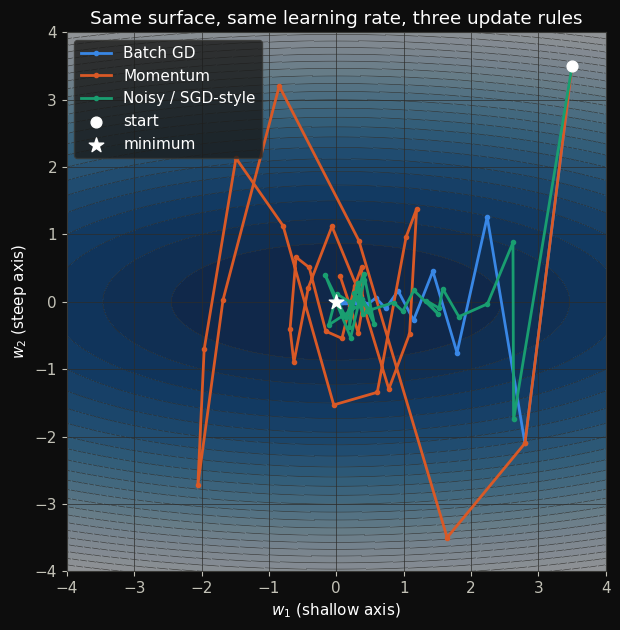

In [6]:
grid_w1 = np.linspace(-4, 4, 200)
grid_w2 = np.linspace(-4, 4, 200)
W1, W2 = np.meshgrid(grid_w1, grid_w2)
Z = 0.5 * (A * W1 ** 2 + B * W2 ** 2)

fig, ax = plt.subplots(figsize=(7, 7))
ax.contourf(W1, W2, Z, levels=25, cmap="Blues_r", alpha=0.55)
ax.contour(W1, W2, Z, levels=25, colors="#2c2c2a", linewidths=0.5)

paths = [("batch", batch_path, "Batch GD"), ("momentum", momentum_path, "Momentum"), ("sgd", sgd_path, "Noisy / SGD-style")]
for key, path, label in paths:
    ax.plot(path[:, 0], path[:, 1], color=COLORS[key], linewidth=2, marker="o", markersize=3, label=label)

ax.scatter(*w_start, color="#ffffff", s=60, zorder=5, label="start")
ax.scatter(0, 0, color="#ffffff", marker="*", s=120, zorder=5, label="minimum")
ax.set_xlabel("$w_1$ (shallow axis)")
ax.set_ylabel("$w_2$ (steep axis)")
ax.set_aspect("equal")
ax.set_title("Same surface, same learning rate, three update rules")
ax.legend(facecolor="#1a1a19", edgecolor="#383835", labelcolor="#ffffff", loc="upper left")
plt.show()

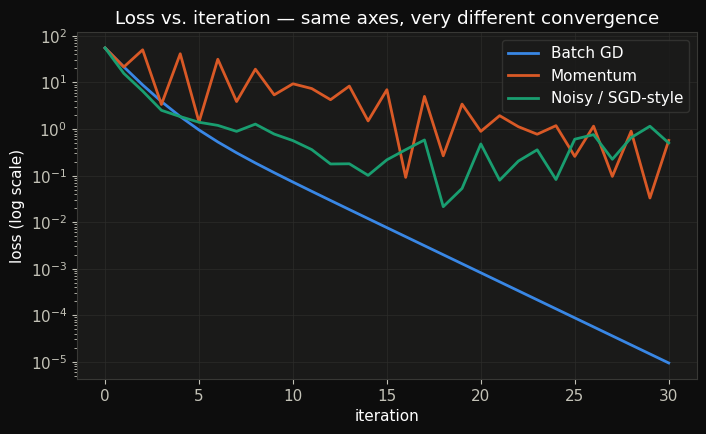

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for key, path, label in paths:
    losses = [loss(w) for w in path]
    ax.plot(losses, color=COLORS[key], linewidth=2, label=label)

ax.set_yscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel("loss (log scale)")
ax.set_title("Loss vs. iteration — same axes, very different convergence")
ax.legend(facecolor="#1a1a19", edgecolor="#383835", labelcolor="#ffffff")
plt.show()

## A harder problem: a local minimum to get stuck in

Real training losses are not convex bowls with one clean minimum — they have shallow local minima, saddle points, and ridges. Here's a small, hand-designed example that has exactly one of each: a **tilted double well** along $w_1$ (two basins of different depth, with a ridge between them) crossed with a plain quadratic along $w_2$.

$$L(w_1, w_2) = k\left(w_1^2 - a^2\right)^2 + c\, w_1 + \tfrac{1}{2} b\, w_2^2$$

With $k=0.06$, $a=1.8$, $c=0.35$, $b=3$: there's a shallow local minimum near $w_1 \approx 1.5$ and a deeper global minimum near $w_1 \approx -2$, with a ridge (a local maximum along $w_1$) near $w_1 \approx 0.5$. A run that starts in the shallow basin has to get *over* that ridge to reach the better answer — and plain gradient descent has no mechanism for that at all.

In [8]:
K, A2, C, B2 = 0.06, 1.8, 0.35, 3.0  # well depth/width, basin separation, tilt, w2 curvature

def trap_loss(w: np.ndarray) -> float:
    return K * (w[0] ** 2 - A2 ** 2) ** 2 + C * w[0] + 0.5 * B2 * w[1] ** 2

def trap_grad(w: np.ndarray) -> np.ndarray:
    gx = 4 * K * w[0] * (w[0] ** 2 - A2 ** 2) + C
    return np.array([gx, B2 * w[1]])

# Confirm the two basins and the ridge between them by scanning w1 with w2=0.
scan = np.linspace(-4, 4, 4000)
scan_grad = np.array([trap_grad(np.array([x, 0.0]))[0] for x in scan])
sign_changes = scan[np.where(np.diff(np.sign(scan_grad)) != 0)[0]]
print("critical points near:", np.round(sign_changes, 2))
print("loss there:", np.round([trap_loss(np.array([x, 0.0])) for x in sign_changes], 3))

critical points near: [-1.99  0.49  1.51]
loss there: [-0.665  0.711  0.584]


Same three update rules, same starting point, dropped into the shallow basin's side of the ridge (`w_start_trap = [2.4, 2.6]`) with the same learning rate (`0.18`) and the same random seed for the noisy variant.

In [9]:
w_start_trap = np.array([2.4, 2.6])
lr_trap = 0.18

def run_batch_gd_generic(w0, lr, n_steps, grad_fn):
    path = np.zeros((n_steps + 1, 2))
    path[0] = w0
    w = w0.copy()
    for t in range(n_steps):
        w = w - lr * grad_fn(w)
        path[t + 1] = w
    return path

def run_momentum_gd_generic(w0, lr, n_steps, grad_fn, beta: float = 0.85):
    path = np.zeros((n_steps + 1, 2))
    path[0] = w0
    w = w0.copy()
    v = np.zeros(2)
    for t in range(n_steps):
        v = beta * v + grad_fn(w)
        w = w - lr * v
        path[t + 1] = w
    return path

def run_noisy_gd_generic(w0, lr, n_steps, grad_fn, noise_scale: float = 1.2, seed: int = 3):
    rng = np.random.default_rng(seed)
    path = np.zeros((n_steps + 1, 2))
    path[0] = w0
    w = w0.copy()
    for t in range(n_steps):
        noise = box_muller(rng, size=2) * noise_scale
        w = w - lr * (grad_fn(w) + noise)
        path[t + 1] = w
    return path


batch_path_trap = run_batch_gd_generic(w_start_trap, lr_trap, 40, trap_grad)
momentum_path_trap = run_momentum_gd_generic(w_start_trap, lr_trap, 40, trap_grad)
sgd_path_trap = run_noisy_gd_generic(w_start_trap, lr_trap, 40, trap_grad, seed=7)

for label, path in [("batch", batch_path_trap), ("momentum", momentum_path_trap), ("sgd", sgd_path_trap)]:
    print(f"{label:10s} final w1={path[-1, 0]:6.2f}  loss={trap_loss(path[-1]):7.3f}")

batch      final w1=  1.51  loss=  0.584
momentum   final w1= -1.96  loss= -0.648
sgd        final w1=  0.00  loss=  0.827


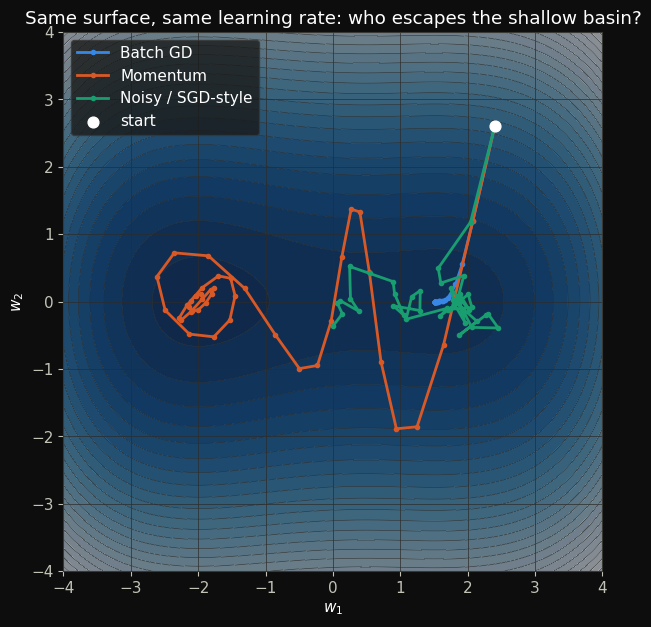

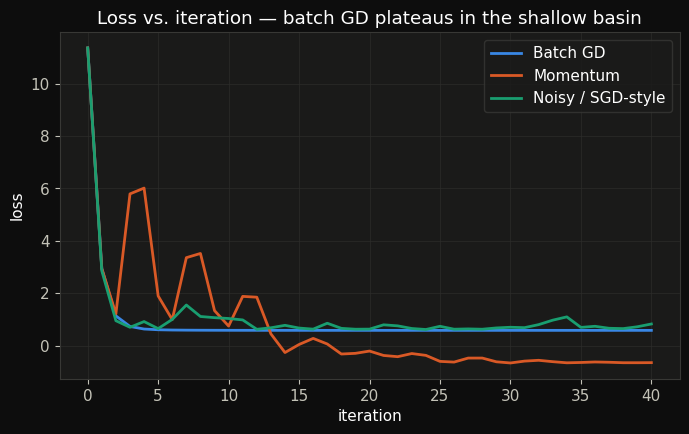

In [10]:
grid_w1 = np.linspace(-4, 4, 200)
grid_w2 = np.linspace(-4, 4, 200)
W1, W2 = np.meshgrid(grid_w1, grid_w2)
Z = K * (W1 ** 2 - A2 ** 2) ** 2 + C * W1 + 0.5 * B2 * W2 ** 2

fig, ax = plt.subplots(figsize=(7, 7))
ax.contourf(W1, W2, Z, levels=25, cmap="Blues_r", alpha=0.55)
ax.contour(W1, W2, Z, levels=25, colors="#2c2c2a", linewidths=0.5)

trap_paths = [
    ("batch", batch_path_trap, "Batch GD"),
    ("momentum", momentum_path_trap, "Momentum"),
    ("sgd", sgd_path_trap, "Noisy / SGD-style"),
]
for key, path, label in trap_paths:
    ax.plot(path[:, 0], path[:, 1], color=COLORS[key], linewidth=2, marker="o", markersize=3, label=label)

ax.scatter(*w_start_trap, color="#ffffff", s=60, zorder=5, label="start")
ax.set_xlabel("$w_1$")
ax.set_ylabel("$w_2$")
ax.set_aspect("equal")
ax.set_title("Same surface, same learning rate: who escapes the shallow basin?")
ax.legend(facecolor="#1a1a19", edgecolor="#383835", labelcolor="#ffffff", loc="upper left")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
for key, path, label in trap_paths:
    losses = [trap_loss(w) for w in path]
    ax.plot(losses, color=COLORS[key], linewidth=2, label=label)
ax.set_xlabel("iteration")
ax.set_ylabel("loss")
ax.set_title("Loss vs. iteration — batch GD plateaus in the shallow basin")
ax.legend(facecolor="#1a1a19", edgecolor="#383835", labelcolor="#ffffff")
plt.show()

## Takeaways

- Gradient descent's only real ingredient is the update rule — everything else (batch, momentum, Adam, RMSProp...) is a variation on "how do we turn a gradient into a step."
- On a lopsided loss surface, vanilla batch GD zig-zags: the learning rate that's stable on the steep axis is too small to make real progress on the shallow one.
- Momentum fixes this by *averaging* gradients over time — oscillating components cancel, consistent components compound.
- Injecting noise into the gradient (a stand-in for mini-batch SGD) makes the path visibly messier, but the noise doesn't necessarily stop convergence — it just makes the descent stochastic instead of deterministic.
- On the two-basin surface, plain batch GD has no way to know a better minimum exists on the other side of the ridge — it converges to whichever basin it started closest to and stops, permanently. Momentum's accumulated velocity can carry a run over the ridge it would otherwise stall at; noise can do the same, but only probabilistically, not on every run.
- Same starting point, same learning rate, same number of steps: the update rule alone is the difference between "still zig-zagging," "stuck in a local minimum," and "already converged."